Customer Retention & Churn Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [ ]:
churn_rate = (df['Churn'].value_counts()['Yes'] / len(df)) * 100

print("Churn Rate:", churn_rate)

Churn Rate: 26.578498293515356


In [ ]:
pd.crosstab(df['gender'], df['Churn'])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [ ]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [ ]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


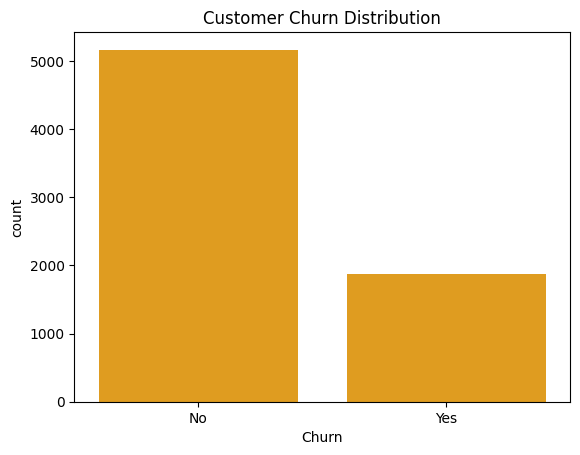

In [ ]:
sns.countplot(x='Churn', data=df,color='orange')

plt.title('Customer Churn Distribution')

plt.show()

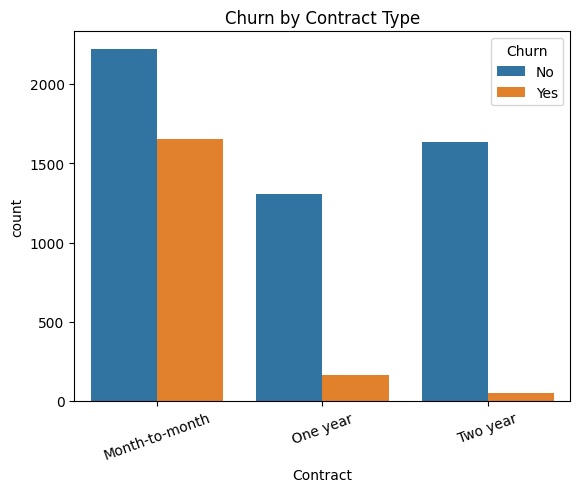

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.xticks(rotation=20)

plt.title('Churn by Contract Type')

plt.show()

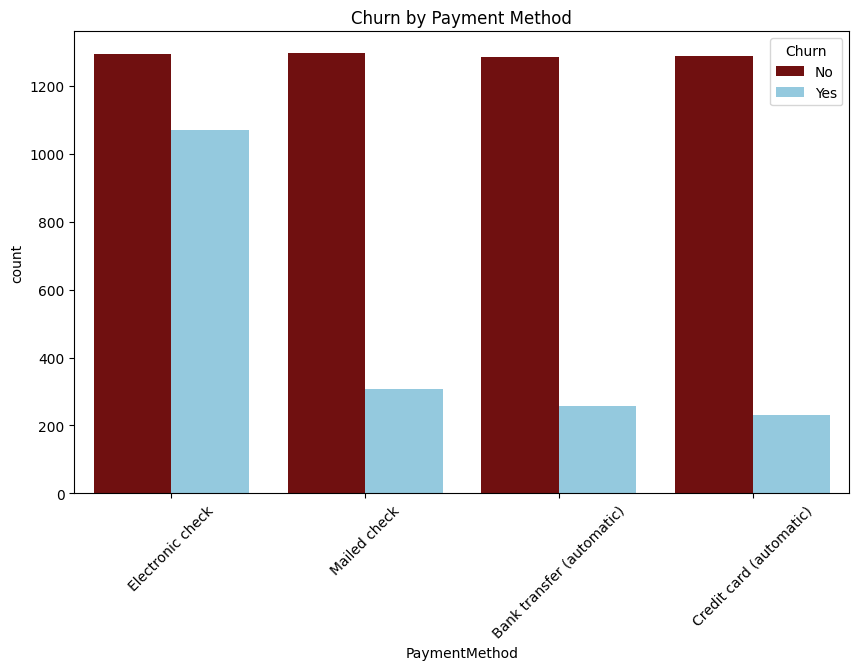

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette=['maroon','skyblue'])

plt.xticks(rotation=45)

plt.title('Churn by Payment Method')

plt.show()

In [ ]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']

In [ ]:
df['CLV'].mean()

np.float64(2283.147248293515)

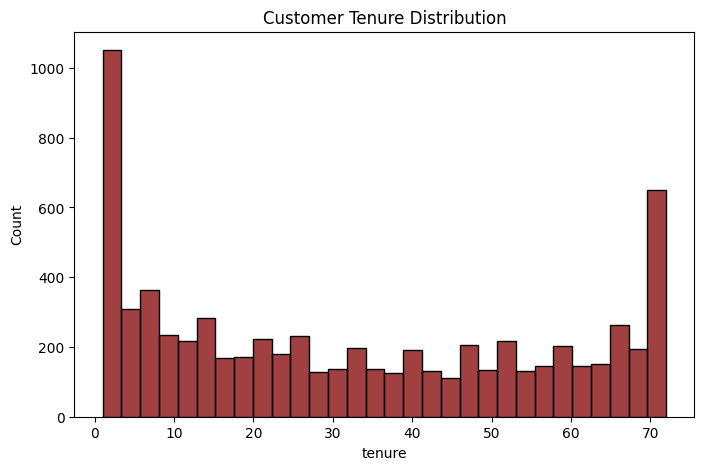

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30, color='maroon')

plt.title('Customer Tenure Distribution')

plt.show()

In [ ]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12','13-24','25-48','49-72']
)


In [ ]:
pd.crosstab(df['TenureGroup'], df['Churn'])

Churn,No,Yes
TenureGroup,,
0-12,1138,1037
13-24,730,294
25-48,1269,325
49-72,2026,213


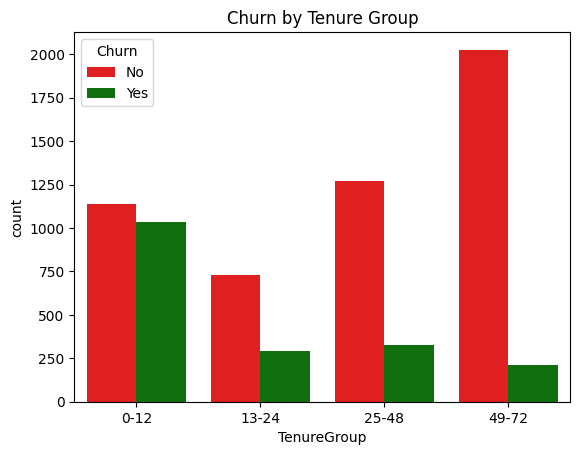

In [ ]:
sns.countplot(x='TenureGroup', hue='Churn', data=df, palette=['red','green'])

plt.title('Churn by Tenure Group')

plt.show()

In [ ]:
df['MonthlyCharges'].sum()

np.float64(455661.0)

In [ ]:
lost_revenue = df[df['Churn']=='Yes']['MonthlyCharges'].sum()

print(lost_revenue)

139130.85


Business Recommendations
## Reduce Early Churn

* Improve customer onboarding process
* Provide tutorials and product guides
* Send welcome and engagement emails to new users
## Increase Retention
* Offer discounts for annual subscriptions
* Introduce loyalty reward programs
* Provide personalized recommendations and offers
## Improve Customer Support
* Reduce customer support response time
* Provide live chat or faster issue resolution
* Create a dedicated customer success team for high-risk customers
## Expected Business Impact
* Lower customer churn
* Higher customer satisfaction
* Increased customer retention
* Improved long-term revenue growth


**# Key Insights**

## Churn Insights

* Customers with month-to-month contracts showed the highest churn rate.
* Most customer churn occurred within the first 12 months of subscription.
* Customers using electronic check payment methods were more likely to leave.
* Higher monthly charges were associated with increased churn probability.
* Long-term contract customers had better retention and loyalty.
* Customers with lower engagement levels were more likely to churn.
* Fiber internet users showed slightly higher churn compared to DSL users.
* Customers with shorter tenure contributed most to revenue loss.

---

# Retention Insights

* Customers with annual contracts stayed active longer.
* Higher tenure customers generated greater customer lifetime value (CLV).
* Loyal customers contributed significantly to recurring revenue.
* Personalized engagement can improve long-term retention.
* Customers with stable payment methods retained better.

---

# Revenue Insights

* Churned customers caused significant monthly revenue loss.
* Long-term subscribers produced higher overall revenue.
* Retaining existing customers is more cost-effective than acquiring new customers.
* Increasing customer retention can directly improve business profitability.

---

# Business Recommendations

## Reduce Early Churn

* Improve onboarding experience for new users.
* Provide tutorials and feature guidance.
* Send welcome and engagement emails during the first month.
* Monitor inactive customers early.


## Increase Customer Retention

* Offer discounts on annual subscription plans.
* Launch loyalty reward and referral programs.
* Provide personalized recommendations and offers.
* Encourage long-term subscriptions.

## Improve Customer Support

* Reduce customer support response time.
* Provide faster issue resolution and live chat support.
* Create a dedicated customer success team.
* Track customer complaints and resolve issues proactively.

# Expected Business Impact

* Reduced customer churn rate.
* Increased customer satisfaction and engagement.
* Higher customer lifetime value.
* Improved recurring revenue and business growth.
